# Ethiopia Food Prices — 08 FEATURE ENGINEERING (cereals & tubers)

Builds a supervised-learning-ready feature matrix from the spike-flagged dataset (`04 SPIKE ANALYSIS`,
cereals & tubers scope), at **market × commodity_unit** series granularity. This is the hand-off point to
the machine-learning forecasting and spike-classification notebooks later in the project — everything here
is built to avoid leaking future information into any feature.

**Scope note**: restricted to cereals & tubers (see `04`). One consequence: the WFP `category` column is
now constant ("cereals and tubers" for every row), so it's dropped as a model feature below — it carries no
information once the whole table is a single category.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', 30)

df = pd.read_csv('../data/eth_food_prices_spikes_cereals.csv', parse_dates=['date'])
df = df.sort_values(['market', 'commodity_unit', 'date']).reset_index(drop=True)
print(f'{len(df):,} rows  |  {df[["market", "commodity_unit"]].drop_duplicates().shape[0]:,} market x commodity_unit series')


23,883 rows  |  829 market x commodity_unit series


## 8.1 Design principles

- Every rolling/lag feature is computed **within each market × commodity_unit series**, sorted by date —
  never mixing one market's history into another's.
- Every rolling statistic uses `.shift(1)` before the rolling window, so a row's features only use
  information available **strictly before** that row's own price — no target leakage.
- Two prediction targets are prepared (for the ML forecasting and spike-classification notebooks
  respectively): next month's price, and next month's spike flag.


## 8.2 Lag features

In [2]:
g = df.groupby(['market', 'commodity_unit'], observed=True)['usdprice']

for lag in [1, 2, 3, 6, 12]:
    df[f'usdprice_lag{lag}'] = g.shift(lag)

df[['market', 'commodity_unit', 'date', 'usdprice', 'usdprice_lag1', 'usdprice_lag3', 'usdprice_lag12']].head(8)


,market,commodity_unit,date,usdprice,usdprice_lag1,usdprice_lag3,usdprice_lag12
0,Abaala,Barley (100 KG),2020-01-15,31.52,NaN,NaN,NaN
1,Abaala,Barley (100 KG),2020-02-15,31.30,31.52,NaN,NaN
2,Abaala,Barley (100 KG),2023-08-15,163.87,31.30,NaN,NaN
3,Abaala,Maize (white) (100 KG),2020-01-15,37.82,NaN,NaN,NaN
4,Abaala,Maize (white) (100 KG),2020-02-15,37.56,37.82,NaN,NaN
5,Abaala,Maize (white) (100 KG),2023-02-15,119.34,37.56,NaN,NaN
6,Abaala,Maize (white) (100 KG),2023-08-15,118.35,119.34,37.82,NaN
7,Abaala,Maize (white) (100 KG),2024-05-15,87.38,118.35,37.56,NaN


## 8.3 Rolling statistics (leakage-safe)

In [3]:
gshift = df.groupby(['market', 'commodity_unit'], observed=True)['usdprice'].shift(1)
df['_shifted'] = gshift

for window in [3, 6, 12]:
    roll = df.groupby(['market', 'commodity_unit'], observed=True)['_shifted'].transform(
        lambda s: s.rolling(window, min_periods=max(2, window // 2)).mean())
    df[f'usdprice_rollmean{window}'] = roll
    roll_std = df.groupby(['market', 'commodity_unit'], observed=True)['_shifted'].transform(
        lambda s: s.rolling(window, min_periods=max(2, window // 2)).std())
    df[f'usdprice_rollstd{window}'] = roll_std

df = df.drop(columns=['_shifted'])
df[['market', 'commodity_unit', 'date', 'usdprice', 'usdprice_rollmean3', 'usdprice_rollstd3', 'usdprice_rollmean12']].dropna().head(8)


,market,commodity_unit,date,usdprice,usdprice_rollmean3,usdprice_rollstd3,usdprice_rollmean12
9,Abaala,Maize (white) (100 KG),2024-07-15,79.72,97.650000,17.926904,81.278333
10,Abaala,Maize (white) (100 KG),2024-09-15,40.48,84.773333,4.377046,81.055714
11,Abaala,Maize (white) (100 KG),2024-10-15,37.89,69.140000,25.101976,75.983750
12,Abaala,Maize (white) (100 KG),2025-01-15,41.30,52.696667,23.438695,71.751111
13,Abaala,Maize (white) (100 KG),2025-02-15,44.17,39.890000,1.779916,68.706000
14,Abaala,Maize (white) (100 KG),2025-03-15,40.05,41.120000,3.143867,66.475455
15,Abaala,Maize (white) (100 KG),2025-05-15,41.48,41.840000,2.112416,64.273333
16,Abaala,Maize (white) (100 KG),2025-06-15,40.95,41.900000,2.091865,64.578333


## 8.4 Recent spike history

In [4]:
spike_shifted = df.groupby(['market', 'commodity_unit'], observed=True)['is_spike'].shift(1)
df['_spike_shifted'] = spike_shifted
df['spike_rate_trailing12'] = df.groupby(['market', 'commodity_unit'], observed=True)['_spike_shifted'].transform(
    lambda s: s.rolling(12, min_periods=3).mean())
df = df.drop(columns=['_spike_shifted'])

df['months_since_last_spike'] = np.nan
for _, idx in df.groupby(['market', 'commodity_unit'], observed=True).groups.items():
    sub = df.loc[idx].sort_values('date')
    last_spike_pos = None
    gaps = []
    for pos, (i, is_spike) in enumerate(zip(sub.index, sub['is_spike'].shift(1).fillna(False))):
        if last_spike_pos is None:
            gaps.append(np.nan)
        else:
            gaps.append(pos - last_spike_pos)
        if is_spike:
            last_spike_pos = pos
    df.loc[sub.index, 'months_since_last_spike'] = gaps

df[['market', 'commodity_unit', 'date', 'is_spike', 'spike_rate_trailing12', 'months_since_last_spike']].dropna().head(8)


,market,commodity_unit,date,is_spike,spike_rate_trailing12,months_since_last_spike
39,Abaala,Pasta (KG),2024-08-15,False,0.111111,1.0
40,Abaala,Pasta (KG),2024-09-15,False,0.100000,2.0
41,Abaala,Pasta (KG),2024-10-15,False,0.090909,3.0
42,Abaala,Pasta (KG),2025-01-15,False,0.083333,4.0
43,Abaala,Pasta (KG),2025-02-15,False,0.083333,5.0
44,Abaala,Pasta (KG),2025-03-15,False,0.083333,6.0
45,Abaala,Pasta (KG),2025-05-15,False,0.083333,7.0
46,Abaala,Pasta (KG),2025-06-15,False,0.083333,8.0


`spike_rate_trailing12` is how often that specific series has spiked in the last 12 months (as of the *previous* month, so it never sees the current row's own spike flag); `months_since_last_spike` is how long it's been since the last one — both are natural predictors for spike-risk modelling in later notebooks.

## 8.5 Calendar features

In [5]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['years_since_start'] = df['year'] - df['year'].min() + (df['month'] - 1) / 12

df[['date', 'month', 'month_sin', 'month_cos', 'years_since_start']].drop_duplicates('date').head(6)


,date,month,month_sin,month_cos,years_since_start
0,2020-01-15,1,5.000000e-01,0.866025,14.000000
1,2020-02-15,2,8.660254e-01,0.500000,14.083333
2,2023-08-15,8,-8.660254e-01,-0.500000,17.583333
5,2023-02-15,2,8.660254e-01,0.500000,17.083333
7,2024-05-15,5,5.000000e-01,-0.866025,18.333333
8,2024-06-15,6,1.224647e-16,-1.000000,18.416667


Cyclical (sine/cosine) encoding lets month-of-year be used by models that assume numeric, unbounded inputs, without an artificial jump between December (12) and January (1).

## 8.6 Relative price position (market premium / discount)

In [6]:
national_median = df.groupby(['commodity_unit', 'date'], observed=True)['usdprice'].transform('median')
df['national_median_usdprice'] = national_median
df['price_premium_pct'] = (df['usdprice'] / df['national_median_usdprice'] - 1) * 100

df[['market', 'commodity_unit', 'date', 'usdprice', 'national_median_usdprice', 'price_premium_pct']].head(8)


,market,commodity_unit,date,usdprice,national_median_usdprice,price_premium_pct
0,Abaala,Barley (100 KG),2020-01-15,31.52,45.380,-30.542089
1,Abaala,Barley (100 KG),2020-02-15,31.30,46.545,-32.753250
2,Abaala,Barley (100 KG),2023-08-15,163.87,80.120,104.530704
3,Abaala,Maize (white) (100 KG),2020-01-15,37.82,34.670,9.085665
4,Abaala,Maize (white) (100 KG),2020-02-15,37.56,35.685,5.254309
5,Abaala,Maize (white) (100 KG),2023-02-15,119.34,65.260,82.868526
6,Abaala,Maize (white) (100 KG),2023-08-15,118.35,81.940,44.434952
7,Abaala,Maize (white) (100 KG),2024-05-15,87.38,72.350,20.774015


`price_premium_pct` captures how expensive a given market is *relative to the national market for that same commodity that same month* — this isolates a market-specific effect (transport cost, local access disruption) from the shared national trend already studied in `03 EDA`.

## 8.7 Prediction targets

In [7]:
df['target_next_usdprice'] = df.groupby(['market', 'commodity_unit'], observed=True)['usdprice'].shift(-1)
df['target_next_pct_change'] = (df['target_next_usdprice'] / df['usdprice'] - 1) * 100
df['target_next_is_spike'] = df.groupby(['market', 'commodity_unit'], observed=True)['is_spike'].shift(-1)

df[['market', 'commodity_unit', 'date', 'usdprice', 'target_next_usdprice', 'target_next_pct_change', 'target_next_is_spike']].head(8)


,market,commodity_unit,date,usdprice,target_next_usdprice,target_next_pct_change,target_next_is_spike
0,Abaala,Barley (100 KG),2020-01-15,31.52,31.30,-0.697970,False
1,Abaala,Barley (100 KG),2020-02-15,31.30,163.87,423.546326,False
2,Abaala,Barley (100 KG),2023-08-15,163.87,NaN,NaN,NaN
3,Abaala,Maize (white) (100 KG),2020-01-15,37.82,37.56,-0.687467,False
4,Abaala,Maize (white) (100 KG),2020-02-15,37.56,119.34,217.731629,False
5,Abaala,Maize (white) (100 KG),2023-02-15,119.34,118.35,-0.829563,False
6,Abaala,Maize (white) (100 KG),2023-08-15,118.35,87.38,-26.168145,False
7,Abaala,Maize (white) (100 KG),2024-05-15,87.38,87.22,-0.183108,False


Two targets are prepared for later notebooks: `target_next_usdprice` / `target_next_pct_change` for the
regression-style forecasting in `09 MACHINE LEARNING FORECASTING`, and `target_next_is_spike` for
`10 SPIKE CLASSIFICATION`. Both are simply each row's own future value, shifted backward onto the current
row — the last row of every series has no target (nothing to shift in) and is naturally `NaN`, as expected.


## 8.8 Feature completeness

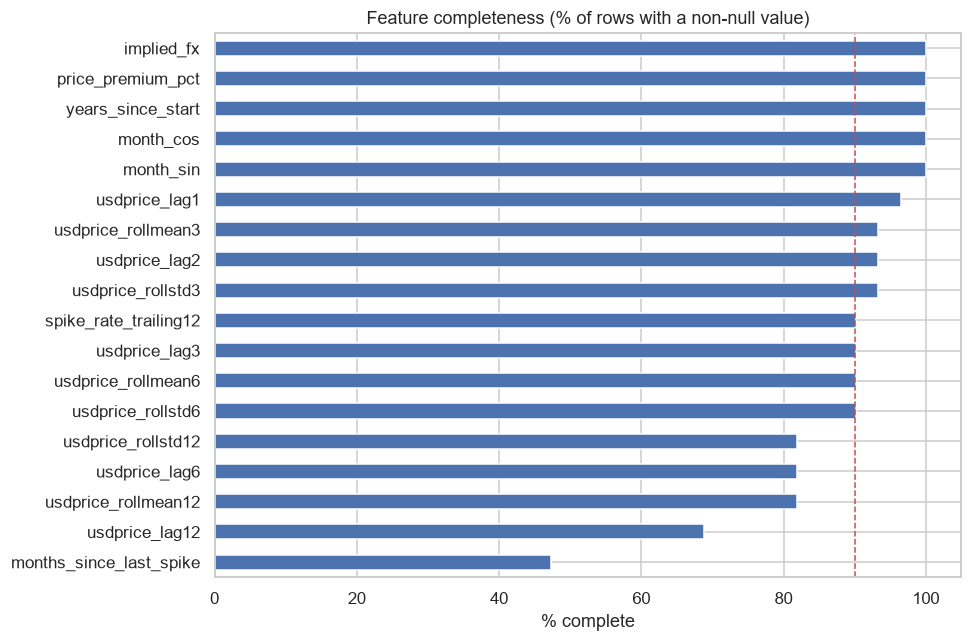

In [8]:
feature_cols = [
    'usdprice_lag1', 'usdprice_lag2', 'usdprice_lag3', 'usdprice_lag6', 'usdprice_lag12',
    'usdprice_rollmean3', 'usdprice_rollstd3', 'usdprice_rollmean6', 'usdprice_rollstd6',
    'usdprice_rollmean12', 'usdprice_rollstd12',
    'spike_rate_trailing12', 'months_since_last_spike',
    'month_sin', 'month_cos', 'years_since_start',
    'price_premium_pct', 'implied_fx',
]

completeness = (1 - df[feature_cols].isna().mean()) * 100
completeness = completeness.sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
completeness.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Feature completeness (% of rows with a non-null value)')
ax.set_xlabel('% complete')
ax.axvline(90, color='#C44E52', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()


As expected, longer-lag and longer-window features (`usdprice_lag12`, `usdprice_rollmean12`,
`spike_rate_trailing12`) are less complete, since they require a full year of prior history for that
specific series — new or short-lived market/commodity series simply don't have that yet. Models trained
downstream will need to either use a feature subset with better coverage, or accept a smaller (but still
substantial) training set when using the full feature list.


In [9]:
complete_rows = df.dropna(subset=feature_cols + ['target_next_usdprice'])
print(f'Rows with every engineered feature AND a valid target: {len(complete_rows):,} of {len(df):,} '
      f'({len(complete_rows) / len(df) * 100:.1f}%)')


Rows with every engineered feature AND a valid target: 10,871 of 23,883 (45.5%)


## 8.9 Sanity check — do the engineered features actually relate to the target?

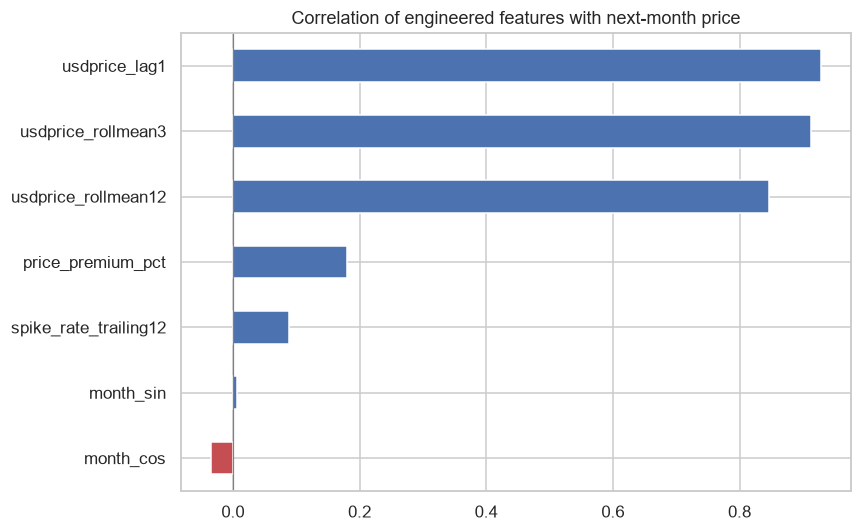

In [10]:
check_cols = ['usdprice_lag1', 'usdprice_rollmean3', 'usdprice_rollmean12', 'price_premium_pct',
              'spike_rate_trailing12', 'month_sin', 'month_cos', 'target_next_usdprice']
corr = complete_rows[check_cols].corr()['target_next_usdprice'].drop('target_next_usdprice').sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
corr.plot(kind='barh', ax=ax, color=['#C44E52' if v < 0 else '#4C72B0' for v in corr.values])
ax.set_title('Correlation of engineered features with next-month price')
ax.axvline(0, color='gray', linewidth=0.8)
plt.tight_layout()
plt.show()


`usdprice_lag1` and the rolling means correlate strongly with next month's price, as expected — recent
price level is the dominant signal, which is exactly why the ARIMA/baseline models in `06`/`07` already do
reasonably well using price history alone. The smaller, non-price features (seasonal encoding, spike
history, regional premium) carry weaker but real linear signal — their value is more likely to show up as
*interactions* (e.g. "high recent spike rate AND lean season") that a tree-based or other non-linear model
in `09 MACHINE LEARNING FORECASTING` can exploit better than a simple correlation can show.


## 8.10 Save the feature matrix

In [11]:
out_cols = (
    ['date', 'admin1', 'admin2', 'market', 'commodity', 'commodity_unit', 'unit', 'pricetype',
     'category', 'usdprice', 'price', 'implied_fx', 'is_spike', 'is_drop', 'pct_change', 'pct_change_z']
    + feature_cols
    + ['target_next_usdprice', 'target_next_pct_change', 'target_next_is_spike']
)
out_cols = list(dict.fromkeys(out_cols))  # drop duplicates (implied_fx appears in both lists)
features_out = df[out_cols].copy()
features_out.to_csv('../data/eth_food_prices_features_cereals.csv', index=False)
print(f'Saved {len(features_out):,} rows x {features_out.shape[1]} columns -> ../data/eth_food_prices_features_cereals.csv')


Saved 23,883 rows x 36 columns -> ../data/eth_food_prices_features_cereals.csv


---
## Summary

- Built a **leakage-safe** feature matrix at market × commodity_unit × month granularity: lags (1–12
  months), rolling mean/std (3/6/12 months), trailing spike rate, months-since-last-spike, cyclical month
  encoding, a linear year trend, and a market's price premium relative to the national median for the same
  commodity and month.
- Prepared two forward-looking targets: `target_next_usdprice` (and `_pct_change`) for regression-style
  forecasting, and `target_next_is_spike` for spike classification.
- Feature completeness drops for longer lag/rolling windows, as expected — the exact share of rows with
  every engineered feature and a valid target is reported in §8.8 above, and that subset is what
  `09 MACHINE LEARNING FORECASTING` and `10 SPIKE CLASSIFICATION` should train on.
- Output: `../data/eth_food_prices_features_cereals.csv`.
